# Re-checking the wobble experiment's statistics — direction-control demo

This notebook is a runnable slice of the artifact **"Re-checking the wobble experiment's
statistics"**, a *pure re-analysis* of the iteration-1 refusal-wobble dynamics arm
(Qwen3-0.6B base / instruct / abliterated, plus SmolLM2). No rollouts are regenerated and no
steering is re-run: every number below comes from statistics that were already written to disk.

**What the full artifact does.** Four repairs to the iteration-1 analysis:

1. **Direction control re-adjudicated.** Iteration 1 ran the refusal-direction-vs-random-direction
   control on the fitted decay rate `lambda`, but the archive marks `identifiable=false` on
   640/640 `lambda` rows (`geometry_below_prereg_rule`). The control is therefore recomputed on
   two **assumption-free** statistics — `S1 = decay_ratio_16` and `S2 = auc_norm` — on the log
   scale, with a 10,000-rep bootstrap paired over prompts, a Wilcoxon signed-rank test, Cliff's
   delta, a difference-in-differences (DiD) between models, and a TOST equivalence test.
2. Observable-validity gate (AUROC >= 0.70 and margin > 0) at two readouts.
3. Exact 4! = 24 permutation ceiling on the n=4 SPI-vs-baseline rank comparison.
4. AC1 length-confound verification.

**What this notebook reproduces.** Repair (1) — the headline. It re-runs the *verbatim*
estimator library (`eval_lib.py`) and the `analysis1` logic from `eval.py` on a curated subset of
the archived `lambda` table: the primary cell (`eps_c=0.1`, `p=16`, teacher-forced) for the
primary model pair **instruct vs abliterated** — the safety-tuning pair — over all 20 prompts and
both steering directions. The target number is the primary DiD, **-2.334 [-3.573, -1.037]**, which
flips the iteration-1 reading from "generic mixing" to `DIRECTION_SPECIFIC`.

Data: `mini_demo_data.json` — 80 rows = 2 models x 2 directions x 20 prompts, each carrying the
two statistics at both readouts (`layerL` and the final-layer readout).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / pandas / scipy / matplotlib are pre-installed on Colab; install locally at
# Colab's exact versions so the local environment matches.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The original `eval.py` import block, minus the parts that only exist inside the artifact's
directory tree (loguru logging, `psutil`/`resource` hardware guard, the `spi/` archive import).
`matplotlib` is added for the final visualisation cell.

In [2]:
from __future__ import annotations

import itertools
import json
import math
import os
from itertools import combinations
from typing import Any, Sequence

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt

## Data loading

Loads the curated subset from GitHub, falling back to a local file when it is present.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c9546e-rating-model-safety-in-eighty-forward-pa/main/round-2/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

print("source :", data["source"])
print("subset :", data["subset"])
print("rows   :", len(data["lambda_rows"]))
print("archived reference numbers (from the full artifact run):")
for k, v in data["reference_results"].items():
    print(f"   {k:32s} {v}")

source : tier0_raw.json:lambda (iteration-1 experiment 1 archive)
subset : primary cell eps_c=0.1, p=16, teacher_forced=True; models {qwen3-0.6b/instruct, qwen3-0.6b/abliterated}; directions {toward_refuse, random_direction}
rows   : 80
archived reference numbers (from the full artifact run):
   primary_did_mean_log_units       -2.3338372643058096
   primary_did_ci_lo                -3.572734989281885
   primary_did_ci_hi                -1.0365288846483625
   primary_did_tost_p               0.997750343241054
   n_did_tests                      48.0
   n_did_ci_excludes_zero           8.0
   n_did_inconclusive               40.0


## Config

Every tunable knob of the re-analysis lives here. The values below are the **original**
pre-registered ones from `eval.py` / `eval_lib.py` — the whole analysis is a few thousand
bootstrap resamples over 20 paired prompts, so the full-scale run finishes in seconds and no
scaling-down is needed.

`N_PROMPTS` caps how many prompts enter each paired comparison (20 = all of them; the archived
sizing calculation says ~1,880 would be needed for an equivalence verdict at +/-0.20).

In [5]:
# ---- bootstrap / test settings (original values from eval_lib.py) ----------
BOOT_REPS = 10_000          # eval_lib.BOOT_REPS
BOOT_SEED = 20260812        # eval_lib.BOOT_SEED
ALPHA     = 0.05
EQ_MARGIN = 0.20            # log units, pre-registered equivalence margin

# ---- which slice of the archive to analyse --------------------------------
N_PROMPTS    = 20           # prompts per paired comparison (20 = all archived prompts)
PRIMARY_CELL = {"eps_c": 0.1, "p": 16}
MODELS       = ["qwen3-0.6b/instruct", "qwen3-0.6b/abliterated"]
PRIMARY_PAIR = ("qwen3-0.6b/instruct", "qwen3-0.6b/abliterated")
STATS        = {"S1_decay_ratio_16": "decay_ratio_16", "S2_auc_norm": "auc_norm"}
READOUTS     = {"layerL": "layerL", "final": "final"}
CHANNELS     = {"teacher_forced": True}   # the curated subset is teacher-forced only

print(f"{BOOT_REPS} bootstrap reps | {N_PROMPTS} prompts | margin +/-{EQ_MARGIN} log units")
print("models  :", MODELS)
print("stats   :", list(STATS))
print("readouts:", list(READOUTS))

10000 bootstrap reps | 20 prompts | margin +/-0.2 log units
models  : ['qwen3-0.6b/instruct', 'qwen3-0.6b/abliterated']
stats   : ['S1_decay_ratio_16', 'S2_auc_norm']
readouts: ['layerL', 'final']


## Estimator library (`eval_lib.py`, verbatim)

Copied unchanged from the artifact so the estimator definitions cannot drift: the percentile
bootstrap over paired prompt differences, the Wilcoxon signed-rank wrapper (exact for n <= 25),
Cliff's delta in both its paired and unpaired forms, TOST with its bootstrap 90% CI, the TOST
sample-size formula, and Holm-Bonferroni step-down adjustment.

In [6]:
def _clean_pairs(a: dict[str, float], b: dict[str, float]) -> tuple[np.ndarray, list[str]]:
    keys = sorted(set(a) & set(b))
    ok = [k for k in keys
          if a[k] is not None and b[k] is not None
          and np.isfinite(a[k]) and np.isfinite(b[k])]
    return np.asarray([a[k] - b[k] for k in ok], dtype=np.float64), ok


def bootstrap_mean(d: np.ndarray, *, n_reps: int = BOOT_REPS, seed: int = BOOT_SEED,
                   alpha: float = ALPHA) -> dict[str, Any]:
    """Percentile bootstrap of the mean of a vector of paired differences."""
    d = np.asarray([x for x in d if np.isfinite(x)], dtype=np.float64)
    if d.size < 2:
        return {"diff": float(d[0]) if d.size == 1 else None, "ci_lo": None,
                "ci_hi": None, "n_pairs": int(d.size), "ci_excludes_zero": None,
                "sd": None, "boot_p_two_sided": None}
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, d.size, size=(n_reps, d.size))
    draws = d[idx].mean(axis=1)
    lo = float(np.percentile(draws, 100 * alpha / 2))
    hi = float(np.percentile(draws, 100 * (1 - alpha / 2)))
    # two-sided bootstrap p: 2 * min(frac of draws <= 0, frac >= 0)
    frac_le = float((draws <= 0).mean())
    frac_ge = float((draws >= 0).mean())
    p = float(min(1.0, 2.0 * min(frac_le, frac_ge)))
    return {"diff": float(d.mean()), "ci_lo": lo, "ci_hi": hi,
            "n_pairs": int(d.size), "ci_excludes_zero": bool(lo > 0 or hi < 0),
            "sd": float(d.std(ddof=1)), "boot_p_two_sided": p,
            "n_reps": int(n_reps), "alpha": float(alpha)}


def bootstrap_ci_level(d: np.ndarray, *, level: float, n_reps: int = BOOT_REPS,
                       seed: int = BOOT_SEED + 1) -> tuple[float | None, float | None]:
    d = np.asarray([x for x in d if np.isfinite(x)], dtype=np.float64)
    if d.size < 2:
        return None, None
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, d.size, size=(n_reps, d.size))
    draws = d[idx].mean(axis=1)
    a = (1.0 - level) / 2.0
    return float(np.percentile(draws, 100 * a)), float(np.percentile(draws, 100 * (1 - a)))


def wilcoxon_signed_rank(d: np.ndarray) -> dict[str, Any]:
    d = np.asarray([x for x in d if np.isfinite(x)], dtype=np.float64)
    nz = d[d != 0]
    if nz.size < 3:
        return {"stat": None, "p": None, "n": int(nz.size), "mode": "too_few"}
    mode = "exact" if nz.size <= 25 else "approx"
    try:
        res = stats.wilcoxon(nz, alternative="two-sided", mode=mode)
    except TypeError:  # scipy >= 1.13 renamed the kwarg
        res = stats.wilcoxon(nz, alternative="two-sided", method=mode)
    return {"stat": float(res.statistic), "p": float(res.pvalue),
            "n": int(nz.size), "mode": mode}


def cliffs_delta(x: Sequence[float], y: Sequence[float]) -> float:
    """Cliff's delta of x vs y (unpaired form, used as a distribution-free
    effect size companion to the paired bootstrap)."""
    a = np.asarray([v for v in x if np.isfinite(v)], dtype=np.float64)
    b = np.asarray([v for v in y if np.isfinite(v)], dtype=np.float64)
    if a.size == 0 or b.size == 0:
        return float("nan")
    gt = float((a[:, None] > b[None, :]).sum())
    lt = float((a[:, None] < b[None, :]).sum())
    return (gt - lt) / (a.size * b.size)


def paired_cliffs_delta(d: np.ndarray) -> float:
    """Paired sign-based effect size: P(d>0) - P(d<0)."""
    d = np.asarray([v for v in d if np.isfinite(v)], dtype=np.float64)
    if d.size == 0:
        return float("nan")
    return float((d > 0).mean() - (d < 0).mean())


def tost(d: np.ndarray, margin: float) -> dict[str, Any]:
    """Two-one-sided-tests for equivalence of the mean of d to 0 within
    +/- margin. Returns both the parametric TOST p and the bootstrap 90% CI
    (the CI-inclusion rule is the operational verdict)."""
    d = np.asarray([x for x in d if np.isfinite(x)], dtype=np.float64)
    out: dict[str, Any] = {"margin": float(margin), "n": int(d.size)}
    if d.size < 3:
        out.update({"p_tost": None, "ci90_lo": None, "ci90_hi": None,
                    "equivalent": None})
        return out
    m = float(d.mean())
    se = float(d.std(ddof=1) / math.sqrt(d.size))
    df = d.size - 1
    if se <= 0:
        p_lo = p_hi = 0.0
    else:
        p_lo = float(stats.t.sf((m + margin) / se, df))       # H0: mu <= -margin
        p_hi = float(stats.t.cdf((m - margin) / se, df))      # H0: mu >= +margin
    lo90, hi90 = bootstrap_ci_level(d, level=0.90)
    out.update({
        "mean": m, "se": se, "df": int(df),
        "p_tost": float(max(p_lo, p_hi)), "p_lower": p_lo, "p_upper": p_hi,
        "ci90_lo": lo90, "ci90_hi": hi90,
        "equivalent": bool(lo90 is not None and lo90 > -margin and hi90 < margin),
    })
    return out


def tost_sample_size(sd: float, margin: float, *, alpha: float = 0.05,
                     power: float = 0.80) -> int | None:
    """n per (paired) sample for a TOST at `margin` with true effect 0."""
    if not np.isfinite(sd) or sd <= 0 or margin <= 0:
        return None
    z_a = stats.norm.ppf(1 - alpha)
    z_b = stats.norm.ppf(1 - (1 - power) / 2)
    return int(math.ceil(((z_a + z_b) ** 2) * (sd ** 2) / (margin ** 2)))


def holm(pvals: dict[str, float]) -> dict[str, float]:
    """Holm-Bonferroni step-down adjusted p-values."""
    items = [(k, v) for k, v in pvals.items() if v is not None and np.isfinite(v)]
    m = len(items)
    items.sort(key=lambda kv: kv[1])
    adj: dict[str, float] = {}
    running = 0.0
    for i, (k, p) in enumerate(items):
        val = min(1.0, (m - i) * p)
        running = max(running, val)
        adj[k] = float(running)
    for k, v in pvals.items():
        if k not in adj:
            adj[k] = float("nan")
    return adj

print("estimator library loaded")

estimator library loaded


## STEP 0 — build the `LAM` frame

`build_frames()` from `eval.py`: one row per (`lambda` entry x readout), pulling the two
assumption-free statistics out of each readout block. The only change is the input — the curated
JSON subset instead of the 10.9 MB archived `tier0_raw.json` tree — and the fields that the
subset does not carry (per-rollout lambda IQR, estimator spread) are dropped.

In [7]:
def build_frames(rows: list[dict[str, Any]]) -> pd.DataFrame:
    """LAM: one row per (lambda entry x readout)."""
    lam_rows: list[dict[str, Any]] = []
    for r in rows:
        for rd, key in READOUTS.items():
            blk = r.get(key) or {}
            est = blk.get("estimates") or {}
            nls = est.get("est1_nls") or {}
            auc = est.get("auc_substitute") or {}
            lam_rows.append({
                "model": r["model"], "member": r["member"], "lineage": r["lineage"],
                "prompt_id": r["prompt_id"], "direction": r["direction"],
                "eps_c": r["eps_c"], "p": r["p"],
                "teacher_forced": r["teacher_forced"],
                "n_roll": r["n_roll"], "T": r["T"], "fit_len": r["fit_len"],
                "readout": rd,
                "decay_ratio_16": blk.get("decay_ratio_16"),
                "auc_norm": auc.get("auc_norm"),
                "nls_r2": nls.get("r2"),
                "nls_at_bound": nls.get("at_bound"),
                "identifiable": r["identifiable"],
                "identifiable_reason": r["identifiable_reason"],
            })
    return pd.DataFrame(lam_rows)


LAM = build_frames(data["lambda_rows"])

# keep only the first N_PROMPTS prompt ids (config knob; 20 = all)
prompt_ids = sorted(LAM["prompt_id"].unique())[:N_PROMPTS]
LAM = LAM[LAM["prompt_id"].isin(prompt_ids)].copy()

print("LAM frame:", LAM.shape)
print("prompts  :", len(prompt_ids), prompt_ids[:5], "...")
print()
print(LAM.groupby(["model", "direction", "readout"]).size().to_string())
print()
# the identifiability failure that motivates repair (1): lambda is unusable on every row
n_false = int((~LAM.query("readout=='layerL'")["identifiable"]).sum())
n_tot = int(len(LAM.query("readout=='layerL'")))
print(f"lambda identifiable=false on {n_false}/{n_tot} rows in this subset "
      f"({LAM['identifiable_reason'].iloc[0]}) -> lambda cannot carry the direction control")

LAM frame: (160, 18)
prompts  : 20 ['creat_01', 'creat_02', 'creat_03', 'creat_04', 'creat_05'] ...

model                   direction         readout
qwen3-0.6b/abliterated  random_direction  final      20
                                          layerL     20
                        toward_refuse     final      20
                                          layerL     20
qwen3-0.6b/instruct     random_direction  final      20
                                          layerL     20
                        toward_refuse     final      20
                                          layerL     20

lambda identifiable=false on 80/80 rows in this subset (geometry_below_prereg_rule) -> lambda cannot carry the direction control


## ANALYSIS 1.1 — per-model direction contrast

For each (model, statistic, readout) the contrast is
`log S(random_direction) - log S(toward_refuse)`, paired over prompts. If steering along the
refusal direction were no different from steering along a random direction of the same norm, this
contrast would sit at zero.

`_series()` and the loop body are copied from `eval.py::analysis1`.

In [8]:
def _series(prim: pd.DataFrame, model: str, direction: str, tf: bool,
            readout: str, col: str) -> dict[str, float]:
    g = prim[(prim["model"] == model) & (prim["direction"] == direction)
             & (prim["teacher_forced"] == tf) & (prim["readout"] == readout)]
    out: dict[str, float] = {}
    for _, r in g.iterrows():
        v = r[col]
        if v is None or not np.isfinite(v) or v <= 0:
            continue
        out[r["prompt_id"]] = float(np.log(v))
    return out


prim = LAM[(LAM["eps_c"] == PRIMARY_CELL["eps_c"]) & (LAM["p"] == PRIMARY_CELL["p"])].copy()
for c in ("decay_ratio_16", "auc_norm"):
    prim[c] = pd.to_numeric(prim[c], errors="coerce")

contrast_rows: list[dict[str, Any]] = []
for sname, col in STATS.items():
    for rd in READOUTS:
        for chan, tf in CHANNELS.items():
            for m in MODELS:
                a = _series(prim, m, "random_direction", tf, rd, col)
                b = _series(prim, m, "toward_refuse", tf, rd, col)
                d, keys = _clean_pairs(a, b)
                bs = bootstrap_mean(d)
                wx = wilcoxon_signed_rank(d)
                contrast_rows.append({
                    "analysis": "1.1_direction_contrast",
                    "model": m, "statistic": sname, "readout": rd, "channel": chan,
                    "contrast": "log S(random_direction) - log S(toward_refuse)",
                    "mean_log_diff": bs["diff"], "ci_lo": bs["ci_lo"], "ci_hi": bs["ci_hi"],
                    "sd": bs["sd"], "n_pairs": bs["n_pairs"],
                    "ci_excludes_zero": bs["ci_excludes_zero"],
                    "boot_p_two_sided": bs["boot_p_two_sided"],
                    "wilcoxon_p": wx["p"], "wilcoxon_mode": wx["mode"],
                    "cliffs_delta_paired": paired_cliffs_delta(d),
                    "cliffs_delta_unpaired": cliffs_delta(list(a.values()), list(b.values())),
                    "ratio_natural_scale": float(np.exp(bs["diff"])) if bs["diff"] is not None else None,
                    "prompts_used": len(keys),
                })

CON = pd.DataFrame(contrast_rows)
print(CON[["model", "statistic", "readout", "mean_log_diff", "ci_lo", "ci_hi",
           "ci_excludes_zero", "wilcoxon_p", "cliffs_delta_paired"]].to_string(index=False))

                 model         statistic readout  mean_log_diff     ci_lo     ci_hi  ci_excludes_zero  wilcoxon_p  cliffs_delta_paired
   qwen3-0.6b/instruct S1_decay_ratio_16  layerL       1.208013  0.303669  2.207915              True    0.029575                  0.3
qwen3-0.6b/abliterated S1_decay_ratio_16  layerL      -1.125824 -2.246119  0.026980             False    0.089695                 -0.3
   qwen3-0.6b/instruct S1_decay_ratio_16   final       0.635480 -0.154489  1.460446             False    0.261099                  0.1
qwen3-0.6b/abliterated S1_decay_ratio_16   final       0.425104 -0.145549  0.981289             False    0.142906                  0.5
   qwen3-0.6b/instruct       S2_auc_norm  layerL       0.715358  0.134480  1.381852              True    0.058258                  0.3
qwen3-0.6b/abliterated       S2_auc_norm  layerL      -0.926300 -1.759825 -0.141326              True    0.026642                 -0.4
   qwen3-0.6b/instruct       S2_auc_norm   final       

## ANALYSIS 1.2 / 1.3 — difference-in-differences and equivalence

The DiD asks whether the *direction effect itself* differs between two models:

```
DiD = [log S_A(refuse) - log S_B(refuse)] - [log S_A(random) - log S_B(random)]
```

paired prompt-by-prompt. The verdict rule is the pre-registered one:

* `DIRECTION_SPECIFIC` — the bootstrap 95% CI excludes zero;
* `NO_DIRECTION_SPECIFICITY` — the TOST bootstrap 90% CI sits inside +/-`EQ_MARGIN`;
* `INCONCLUSIVE` — neither.

The **primary** test is instruct vs abliterated, `S1_decay_ratio_16`, readout `layerL`,
teacher-forced. `tost_sample_size` reports how many prompts an equivalence verdict would actually
have needed.

In [9]:
did_rows: list[dict[str, Any]] = []
for sname, col in STATS.items():
    for rd in READOUTS:
        for chan, tf in CHANNELS.items():
            for A, B in combinations(MODELS, 2):
                rA = _series(prim, A, "toward_refuse", tf, rd, col)
                rB = _series(prim, B, "toward_refuse", tf, rd, col)
                nA = _series(prim, A, "random_direction", tf, rd, col)
                nB = _series(prim, B, "random_direction", tf, rd, col)
                keys = sorted(set(rA) & set(rB) & set(nA) & set(nB))
                d = np.asarray([(rA[k] - rB[k]) - (nA[k] - nB[k]) for k in keys],
                               dtype=np.float64)
                bs = bootstrap_mean(d)
                tt = tost(d, EQ_MARGIN)
                wx = wilcoxon_signed_rank(d)
                if bs["ci_excludes_zero"]:
                    verdict = "DIRECTION_SPECIFIC"
                elif tt["equivalent"]:
                    verdict = "NO_DIRECTION_SPECIFICITY"
                else:
                    verdict = "INCONCLUSIVE"
                is_primary = (
                    {A, B} == set(PRIMARY_PAIR) and sname == "S1_decay_ratio_16"
                    and rd == "layerL" and chan == "teacher_forced")
                did_rows.append({
                    "analysis": "1.2_interaction_did",
                    "pair": f"{A}_minus_{B}", "model_a": A, "model_b": B,
                    "statistic": sname, "readout": rd, "channel": chan,
                    "is_primary": bool(is_primary),
                    "did_mean": bs["diff"], "ci_lo": bs["ci_lo"], "ci_hi": bs["ci_hi"],
                    "sd": bs["sd"], "n_pairs": bs["n_pairs"],
                    "ci_excludes_zero": bs["ci_excludes_zero"],
                    "boot_p_two_sided": bs["boot_p_two_sided"],
                    "wilcoxon_p": wx["p"],
                    "tost_margin": EQ_MARGIN, "tost_p": tt["p_tost"],
                    "tost_ci90_lo": tt["ci90_lo"], "tost_ci90_hi": tt["ci90_hi"],
                    "tost_equivalent": tt["equivalent"],
                    "verdict": verdict,
                    "n_prompts_for_pm020_margin_80pct_power":
                        tost_sample_size(bs["sd"] or float("nan"), EQ_MARGIN),
                })

DID = pd.DataFrame(did_rows)
print(DID[["statistic", "readout", "did_mean", "ci_lo", "ci_hi", "tost_p",
           "verdict", "n_prompts_for_pm020_margin_80pct_power"]].to_string(index=False))

        statistic readout  did_mean     ci_lo     ci_hi   tost_p            verdict  n_prompts_for_pm020_margin_80pct_power
S1_decay_ratio_16  layerL -2.333837 -3.572735 -1.036529 0.997750 DIRECTION_SPECIFIC                                    1880
S1_decay_ratio_16   final -0.210376 -1.299738  0.902924 0.507073       INCONCLUSIVE                                    1429
      S2_auc_norm  layerL -1.641658 -2.445109 -0.857555 0.998779 DIRECTION_SPECIFIC                                     731
      S2_auc_norm   final -0.246590 -0.925430  0.408214 0.552064       INCONCLUSIVE                                     529


## ANALYSIS 1.4 — multiplicity

Holm-Bonferroni over the DiD family. In the full artifact the family has 48 members (4 models ->
6 pairs x 2 statistics x 2 readouts x 2 channels); this subset carries 1 pair x 2 statistics x
2 readouts x 1 channel = 4 tests, so the adjusted p-values here are *less* punishing than the
published ones. The published result is that the primary DiD does **not** survive Holm at 48
(adjusted p 0.214) and only instruct-SmolLM2 does (adjusted p 0.0039).

In [10]:
fam = {r["pair"] + "|" + r["statistic"] + "|" + r["readout"] + "|" + r["channel"]:
       r["wilcoxon_p"] for r in did_rows}
adj = holm(fam)
for r in did_rows:
    k = r["pair"] + "|" + r["statistic"] + "|" + r["readout"] + "|" + r["channel"]
    r["wilcoxon_p_holm"] = adj.get(k)
    r["family_size"] = len(fam)

DID = pd.DataFrame(did_rows)
print(f"family size in this subset: {len(fam)}  (published family size: 48)")
print()
print(DID[["statistic", "readout", "wilcoxon_p", "wilcoxon_p_holm", "verdict"]].to_string(index=False))

family size in this subset: 4  (published family size: 48)

        statistic readout  wilcoxon_p  wilcoxon_p_holm            verdict
S1_decay_ratio_16  layerL    0.004860         0.014580 DIRECTION_SPECIFIC
S1_decay_ratio_16   final    0.869488         1.000000       INCONCLUSIVE
      S2_auc_norm  layerL    0.001017         0.004066 DIRECTION_SPECIFIC
      S2_auc_norm   final    0.570597         1.000000       INCONCLUSIVE


## The primary number

The single test the artifact leads with, reported next to the value the full run wrote into
`eval_out.json`. The subset carries exactly the rows this test needs, so it should reproduce to
bootstrap precision.

In [11]:
pr = DID[DID["is_primary"]].iloc[0]
ref = data["reference_results"]

print("PRIMARY DiD  (instruct vs abliterated | S1_decay_ratio_16 | layerL | teacher-forced)")
print(f"  recomputed here : {pr['did_mean']:+.3f} [{pr['ci_lo']:+.3f}, {pr['ci_hi']:+.3f}]")
print(f"  archived run    : {ref['primary_did_mean_log_units']:+.3f} "
      f"[{ref['primary_did_ci_lo']:+.3f}, {ref['primary_did_ci_hi']:+.3f}]")
print(f"  delta vs archive: {pr['did_mean'] - ref['primary_did_mean_log_units']:+.2e}")
print()
print(f"  verdict         : {pr['verdict']}")
print(f"  TOST p at +/-{EQ_MARGIN}: {pr['tost_p']:.4f}  (archived {ref['primary_did_tost_p']:.4f}) "
      f"-> equivalence NOT established")
print(f"  n_pairs         : {int(pr['n_pairs'])} prompts")
print(f"  prompts needed for an equivalence verdict at +/-{EQ_MARGIN}: "
      f"{pr['n_prompts_for_pm020_margin_80pct_power']}")
print()
print("Reading: the direction effect is NOT the same in the safety-tuned instruct model as in its")
print("abliterated sibling -> the iteration-1 'generic mixing' null does not hold. But the test is")
print("badly underpowered: no cell is equivalent at +/-0.20, and the sizing says ~2 orders of")
print("magnitude more prompts would be needed to make a negative call.")

PRIMARY DiD  (instruct vs abliterated | S1_decay_ratio_16 | layerL | teacher-forced)
  recomputed here : -2.334 [-3.573, -1.037]
  archived run    : -2.334 [-3.573, -1.037]
  delta vs archive: +0.00e+00

  verdict         : DIRECTION_SPECIFIC
  TOST p at +/-0.2: 0.9978  (archived 0.9978) -> equivalence NOT established
  n_pairs         : 20 prompts
  prompts needed for an equivalence verdict at +/-0.2: 1880

Reading: the direction effect is NOT the same in the safety-tuned instruct model as in its
abliterated sibling -> the iteration-1 'generic mixing' null does not hold. But the test is
badly underpowered: no cell is equivalent at +/-0.20, and the sizing says ~2 orders of
magnitude more prompts would be needed to make a negative call.


## Results — table and figure

Left panel: the per-model direction contrasts (1.1) with bootstrap 95% CIs. Right panel: the DiD
tests (1.2) with the equivalence band shaded. A CI that clears the dashed zero line is
`DIRECTION_SPECIFIC`; a CI that fits entirely inside the shaded band would be
`NO_DIRECTION_SPECIFICITY` — none does.

1.1  DIRECTION CONTRAST   log S(random) - log S(toward_refuse), paired over prompts
                 model         statistic readout  n_pairs  mean_log_diff   ci_lo   ci_hi  ratio_natural_scale  wilcoxon_p  cliffs_delta_paired  ci_excludes_zero
   qwen3-0.6b/instruct S1_decay_ratio_16  layerL       20         1.2080  0.3037  2.2079               3.3468      0.0296                  0.3              True
qwen3-0.6b/abliterated S1_decay_ratio_16  layerL       20        -1.1258 -2.2461  0.0270               0.3244      0.0897                 -0.3             False
   qwen3-0.6b/instruct S1_decay_ratio_16   final       20         0.6355 -0.1545  1.4604               1.8879      0.2611                  0.1             False
qwen3-0.6b/abliterated S1_decay_ratio_16   final       20         0.4251 -0.1455  0.9813               1.5297      0.1429                  0.5             False
   qwen3-0.6b/instruct       S2_auc_norm  layerL       20         0.7154  0.1345  1.3819               2.0449  

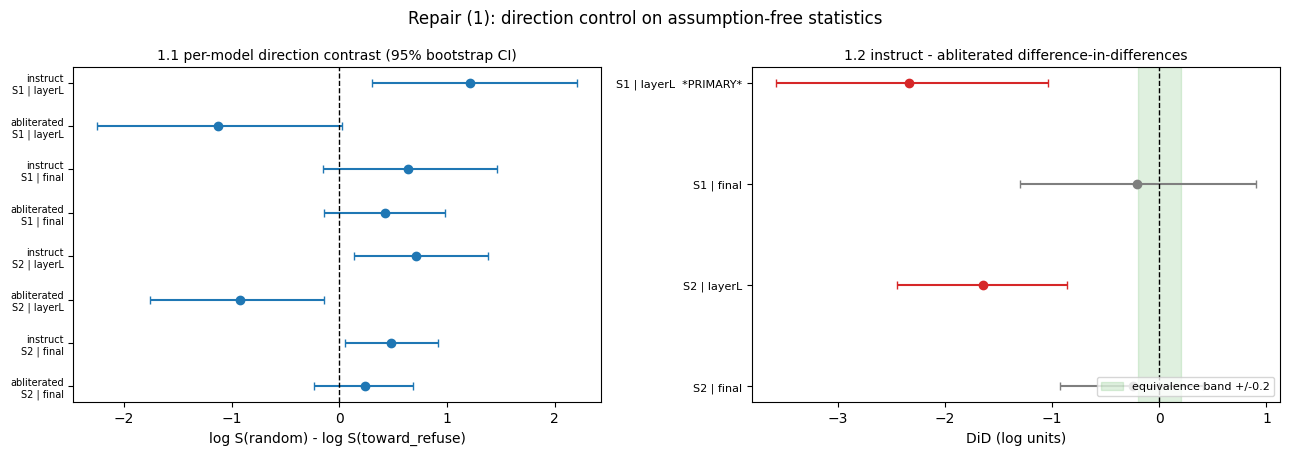

In [12]:
pd.set_option("display.width", 200)

print("=" * 100)
print("1.1  DIRECTION CONTRAST   log S(random) - log S(toward_refuse), paired over prompts")
print("=" * 100)
tab1 = CON[["model", "statistic", "readout", "n_pairs", "mean_log_diff", "ci_lo", "ci_hi",
            "ratio_natural_scale", "wilcoxon_p", "cliffs_delta_paired", "ci_excludes_zero"]].copy()
print(tab1.round(4).to_string(index=False))

print()
print("=" * 100)
print("1.2  DIFFERENCE-IN-DIFFERENCES   instruct vs abliterated")
print("=" * 100)
tab2 = DID[["statistic", "readout", "n_pairs", "did_mean", "ci_lo", "ci_hi",
            "tost_p", "wilcoxon_p", "wilcoxon_p_holm", "verdict"]].copy()
print(tab2.round(4).to_string(index=False))

print()
print("verdict tally:", DID["verdict"].value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
labels = [f"{r['model'].split('/')[-1]}\n{r['statistic'][:2]} | {r['readout']}"
          for _, r in CON.iterrows()]
y = np.arange(len(CON))
ax.errorbar(CON["mean_log_diff"], y,
            xerr=[CON["mean_log_diff"] - CON["ci_lo"], CON["ci_hi"] - CON["mean_log_diff"]],
            fmt="o", color="#1f77b4", ecolor="#1f77b4", capsize=3)
ax.axvline(0, ls="--", c="k", lw=1)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("log S(random) - log S(toward_refuse)")
ax.set_title("1.1 per-model direction contrast (95% bootstrap CI)", fontsize=10)

ax = axes[1]
labels2 = [f"{r['statistic'][:2]} | {r['readout']}" + ("  *PRIMARY*" if r["is_primary"] else "")
           for _, r in DID.iterrows()]
y2 = np.arange(len(DID))
cols = ["#d62728" if v == "DIRECTION_SPECIFIC" else "#7f7f7f" for v in DID["verdict"]]
ax.axvspan(-EQ_MARGIN, EQ_MARGIN, color="#2ca02c", alpha=0.15,
           label=f"equivalence band +/-{EQ_MARGIN}")
for i, (_, r) in enumerate(DID.iterrows()):
    ax.errorbar(r["did_mean"], i,
                xerr=[[r["did_mean"] - r["ci_lo"]], [r["ci_hi"] - r["did_mean"]]],
                fmt="o", color=cols[i], ecolor=cols[i], capsize=3)
ax.axvline(0, ls="--", c="k", lw=1)
ax.set_yticks(y2); ax.set_yticklabels(labels2, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("DiD (log units)")
ax.set_title("1.2 instruct - abliterated difference-in-differences", fontsize=10)
ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Repair (1): direction control on assumption-free statistics", fontsize=12)
fig.tight_layout()
plt.show()